# Ejemplo 4 (Alternativo) — PSO para Clustering

**Actividad 03 — Algoritmos de Enjambre aplicados al Aprendizaje Automático**

## Ejemplo alternativo (+3): clustering mediante PSO

Se utiliza PSO para encontrar los centroides de 3 grupos en el dataset Iris.

### Representación

Cada partícula contiene 12 valores:

`3 centroides × 4 características = 12 dimensiones`

### Aptitud

Se minimiza la suma de cuadrados intra-cluster (**SSE**).

Las etiquetas reales de Iris **no participan en la optimización**. Solo se usan al final para calcular ARI como evaluación externa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEMILLA = 42

datos = load_iris()
X = StandardScaler().fit_transform(datos.data)
y_real = datos.target

K = 3
N_FEATURES = X.shape[1]
DIMENSION = K * N_FEATURES

limite_inferior = np.tile(X.min(axis=0), K)
limite_superior = np.tile(X.max(axis=0), K)

print("Registros:", X.shape[0])
print("Características:", N_FEATURES)
print("Clusters buscados:", K)
print("Dimensión de cada partícula:", DIMENSION)

Registros: 150
Características: 4
Clusters buscados: 3
Dimensión de cada partícula: 12


In [2]:
def centroides_desde_particula(particula):
    return particula.reshape(K, N_FEATURES)

def evaluar_clustering(particula):
    centroides = centroides_desde_particula(particula)

    distancias = np.sum(
        (X[:, None, :] - centroides[None, :, :]) ** 2,
        axis=2
    )

    etiquetas = np.argmin(distancias, axis=1)
    sse = np.sum(
        distancias[np.arange(len(X)), etiquetas]
    )

    return sse, etiquetas

In [3]:
def pso_clustering(
    numero_particulas=15,
    iteraciones=25,
    w=0.72,
    c1=1.49,
    c2=1.49
):
    rng = np.random.default_rng(SEMILLA)

    posiciones = rng.uniform(
        limite_inferior,
        limite_superior,
        size=(numero_particulas, DIMENSION)
    )
    velocidades = np.zeros_like(posiciones)

    sse_actual = np.array([
        evaluar_clustering(p)[0]
        for p in posiciones
    ])

    pbest_posiciones = posiciones.copy()
    pbest_sse = sse_actual.copy()

    indice = int(np.argmin(pbest_sse))
    gbest_posicion = pbest_posiciones[indice].copy()
    gbest_sse = pbest_sse[indice]

    historial = []

    for it in range(1, iteraciones + 1):
        r1 = rng.random(posiciones.shape)
        r2 = rng.random(posiciones.shape)

        velocidades = (
            w * velocidades
            + c1 * r1 * (pbest_posiciones - posiciones)
            + c2 * r2 * (gbest_posicion - posiciones)
        )

        posiciones = posiciones + velocidades
        posiciones = np.clip(
            posiciones,
            limite_inferior,
            limite_superior
        )

        sse_actual = np.array([
            evaluar_clustering(p)[0]
            for p in posiciones
        ])

        mejoraron = sse_actual < pbest_sse
        pbest_posiciones[mejoraron] = posiciones[mejoraron]
        pbest_sse[mejoraron] = sse_actual[mejoraron]

        indice = int(np.argmin(pbest_sse))
        if pbest_sse[indice] < gbest_sse:
            gbest_posicion = pbest_posiciones[indice].copy()
            gbest_sse = pbest_sse[indice]

        historial.append({
            "iteracion": it,
            "mejor_sse": gbest_sse
        })

        if it == 1 or it % 5 == 0 or it == iteraciones:
            print(f"Iteración {it:02d} | Mejor SSE: {gbest_sse:.4f}")

    return gbest_posicion, gbest_sse, pd.DataFrame(historial)

mejor_particula_cluster, mejor_sse, historial_cluster = pso_clustering()

Iteración 01 | Mejor SSE: 392.8037
Iteración 05 | Mejor SSE: 289.0807
Iteración 10 | Mejor SSE: 195.6001
Iteración 15 | Mejor SSE: 161.8166
Iteración 20 | Mejor SSE: 149.2982
Iteración 25 | Mejor SSE: 145.1457


In [4]:
sse_final, etiquetas_cluster = evaluar_clustering(mejor_particula_cluster)
silhouette = silhouette_score(X, etiquetas_cluster)
ari = adjusted_rand_score(y_real, etiquetas_cluster)

print("\nRESULTADO FINAL CLUSTERING")
print("=" * 60)
print(f"SSE final: {sse_final:.4f}")
print(f"Silhouette: {silhouette:.4f}")
print(f"ARI (solo evaluación externa): {ari:.4f}")
print("\nCentroides encontrados (espacio estandarizado):")
print(centroides_desde_particula(mejor_particula_cluster))


RESULTADO FINAL CLUSTERING
SSE final: 145.1457
Silhouette: 0.4536
ARI (solo evaluación externa): 0.6525

Centroides encontrados (espacio estandarizado):
[[-0.14260503 -0.8454872   0.43647189  0.08562892]
 [ 0.97454706 -0.11779886  1.08304658  1.00160244]
 [-1.02091675  0.84669122 -1.38606483 -1.24308571]]


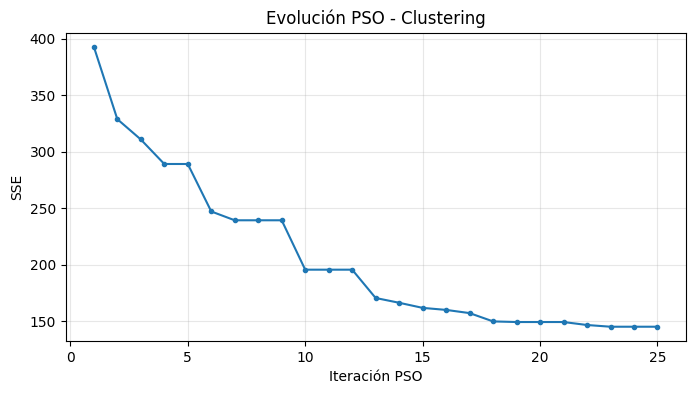

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(historial_cluster["iteracion"], historial_cluster["mejor_sse"], marker="o", markersize=3)
plt.xlabel("Iteración PSO")
plt.ylabel("SSE")
plt.title("Evolución PSO - Clustering")
plt.grid(alpha=0.3)
plt.show()